# Augmentation Training

This notebook trains the same baseline CNN architecture using data augmentation to evaluate whether exposure to transformed training images improves clean generalization and robustness to image corruptions.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

In [2]:
# CIFAR-10 normalization statistics
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

# Training transform with data augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(
        size=32,
        padding=4
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation and test transform
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load CIFAR-10 datasets
train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=train_transform
)

val_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=eval_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=eval_transform
)

# Reproduce the same train/validation split used for the baseline model
all_indices = np.arange(len(train_dataset))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=42,
    stratify=train_dataset.targets
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Test samples:", len(test_dataset))

Training samples: 45000
Validation samples: 5000
Test samples: 10000


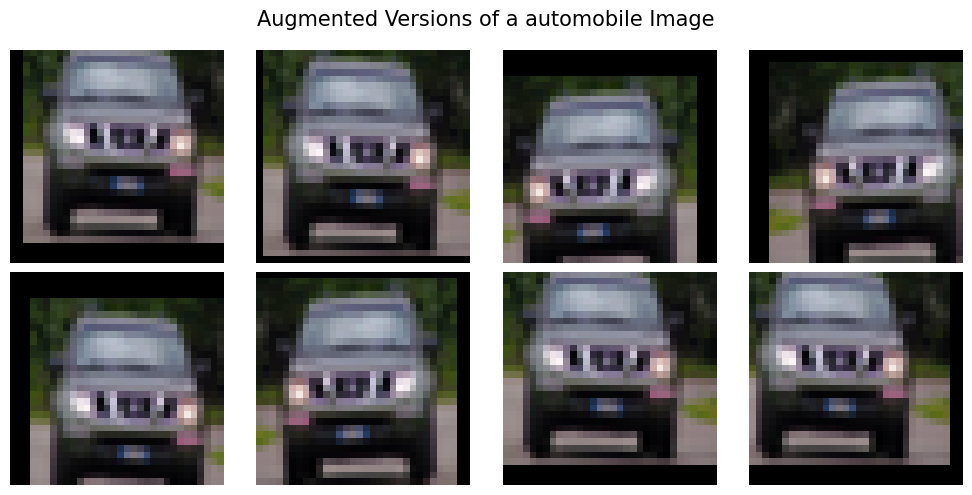

In [3]:
# Visualize multiple augmented versions of the same training image
sample_index = train_indices[0]
label = train_dataset.targets[sample_index]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for ax in axes.flat:
    image, _ = train_dataset[sample_index]

    # Denormalize for visualization
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    image = image * std_tensor + mean_tensor
    image = torch.clamp(image, 0.0, 1.0)

    ax.imshow(image.permute(1, 2, 0))
    ax.axis("off")

fig.suptitle(
    f"Augmented Versions of a {train_dataset.classes[label]} Image",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [4]:
# Define the same CNN architecture used for the baseline model
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Set random seed for reproducibility
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Set checkpoint path
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

checkpoint_path = models_dir / "augmented_cnn_best.pth"

# Check model output on one validation batch
model.eval()

images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    loss = criterion(outputs, labels)

print("\nOutput shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Initial loss:", loss.item())

Device: cuda

Output shape: torch.Size([128, 10])
Labels shape: torch.Size([128])
Initial loss: 2.3075520992279053


In [5]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [6]:
def validate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [7]:
# Training settings
num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print(
    f"\nBest model: Epoch {best_epoch} "
    f"with validation loss {best_val_loss:.4f}"
)

Epoch 01/10 | Train Loss: 1.6765 | Train Acc: 0.3874 | Val Loss: 1.3452 | Val Acc: 0.5172
Epoch 02/10 | Train Loss: 1.3768 | Train Acc: 0.5038 | Val Loss: 1.1563 | Val Acc: 0.5858
Epoch 03/10 | Train Loss: 1.2446 | Train Acc: 0.5536 | Val Loss: 1.0563 | Val Acc: 0.6126
Epoch 04/10 | Train Loss: 1.1628 | Train Acc: 0.5841 | Val Loss: 0.9815 | Val Acc: 0.6556
Epoch 05/10 | Train Loss: 1.1053 | Train Acc: 0.6056 | Val Loss: 0.9086 | Val Acc: 0.6790
Epoch 06/10 | Train Loss: 1.0616 | Train Acc: 0.6233 | Val Loss: 0.8939 | Val Acc: 0.6868
Epoch 07/10 | Train Loss: 1.0251 | Train Acc: 0.6365 | Val Loss: 0.8327 | Val Acc: 0.7056
Epoch 08/10 | Train Loss: 1.0062 | Train Acc: 0.6463 | Val Loss: 0.8233 | Val Acc: 0.7040
Epoch 09/10 | Train Loss: 0.9710 | Train Acc: 0.6581 | Val Loss: 0.7983 | Val Acc: 0.7166
Epoch 10/10 | Train Loss: 0.9562 | Train Acc: 0.6604 | Val Loss: 0.8008 | Val Acc: 0.7158

Best model: Epoch 9 with validation loss 0.7983


### Augmented Training Results

Training with random cropping and horizontal flipping produced a best validation loss of `0.7983` at epoch 9, with a validation accuracy of `71.66%`.

Compared with the baseline CNN, clean validation performance remained similar despite the augmented model achieving lower training accuracy. This is expected because the model is trained on randomly transformed images with dropout enabled, while validation is performed on unaugmented images with dropout disabled.

The augmented model therefore maintains approximately the same clean validation performance as the baseline. The next step is to determine whether this training strategy improves robustness under image corruption.

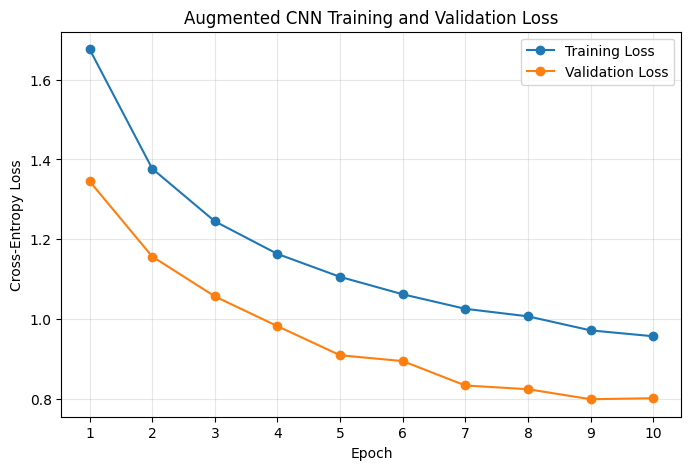

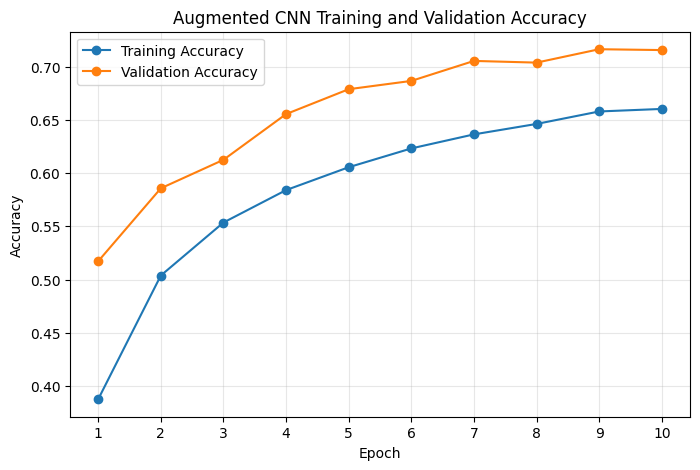

In [11]:
epochs = range(1, num_epochs + 1)

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Augmented CNN Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Augmented CNN Training and Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Training loss remained higher than validation loss, while training accuracy remained lower than validation accuracy throughout training. This is expected because training metrics are measured on randomly augmented inputs with dropout enabled, whereas validation is performed on unaugmented inputs with dropout disabled.